<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/20%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
RBM + Logistic Regression Test Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9984 - loss: 0.0072

Simple RNN Test Accuracy: 0.998
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 2.2984e-04

LSTM Test Accuracy: 1.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


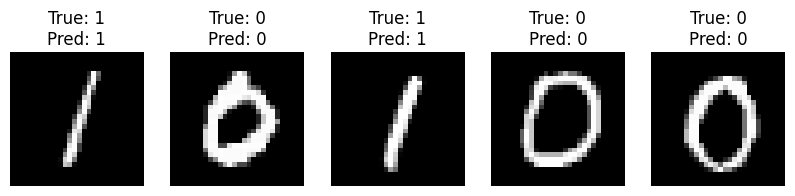

In [ ]:
# 1️⃣ Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import BernoulliRBM
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# 2️⃣ Load MNIST dataset (digits 0-1 for binary demonstration)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Binary classification: 0 vs 1
train_filter = np.where((y_train == 0) | (y_train == 1))
test_filter = np.where((y_test == 0) | (y_test == 1))
X_train, y_train = X_train[train_filter], y_train[train_filter]
X_test, y_test = X_test[test_filter], y_test[test_filter]

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten for RBM
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# ============================
# 3️⃣ Restricted Boltzmann Machine (RBM)
# ============================
rbm = BernoulliRBM(n_components=100, learning_rate=0.01, n_iter=20, random_state=42)
logistic = LogisticRegression(solver='lbfgs')
rbm_pipeline = Pipeline(steps=[('rbm', rbm), ('logistic', logistic)])

# Train
rbm_pipeline.fit(X_train_flat, y_train)
y_pred_rbm = rbm_pipeline.predict(X_test_flat)
acc_rbm = accuracy_score(y_test, y_pred_rbm)
print(f"RBM + Logistic Regression Test Accuracy: {acc_rbm:.3f}")
print(classification_report(y_test, y_pred_rbm))

# ============================
# 4️⃣ Simple RNN
# ============================
# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

rnn_model = Sequential([
    SimpleRNN(50, input_shape=(28,28), activation='tanh'),
    Dense(2, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, verbose=0, validation_split=0.2)

loss_rnn, acc_rnn = rnn_model.evaluate(X_test, y_test_cat)
print(f"\nSimple RNN Test Accuracy: {acc_rnn:.3f}")

# ============================
# 5️⃣ LSTM
# ============================
lstm_model = Sequential([
    LSTM(50, input_shape=(28,28), activation='tanh'),
    Dense(2, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, verbose=0, validation_split=0.2)

loss_lstm, acc_lstm = lstm_model.evaluate(X_test, y_test_cat)
print(f"\nLSTM Test Accuracy: {acc_lstm:.3f}")

# ============================
# 6️⃣ Visualization: Random samples and predictions from LSTM
# ============================
y_pred_lstm = np.argmax(lstm_model.predict(X_test[:5]), axis=1)

plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {y_pred_lstm[i]}")
    plt.axis('off')
plt.show()
